# AIBT108 - Introduction to Reinforcement Learning - Python workshop
### *Markov Decision Processes (MDPs) and Reinforcement Learning (RL)*
### April, 2026

***

*The purpose of this tutorial is to learn how to implement **Probabilistic Planning** and **Reinforcement Learning algorithms** on different environments. RL environments are from [Gym (now Gymnasium)](https://www.gymlibrary.dev/index.html).*

***

### Overview

1. In the first section, a planning problem (environment) is defined as a Markov Decision Process, and then solved with **Value Iteration (VI)** algorithm and **Policy Iteration** algorithm (PI).
2. In the second section, some **RL algorithms** (SARSA and Q-learning) are implemented and trained on the "Taxi" environment.
3. In the last section, the same RL algorithms are tested on other environments.

### Instructions

- *The code must be completed for each **Exercise** to work, where `# HERE` appears as a comment in the code.* 
- *DON'T MODIFY THE CODE ELSEWHERE!*
- *There is also one **Question** (a short text answer is expected there)*.
- *Look at the **Examples** section of the documentation pages to be sure of the syntax of your Python code.*
- *Install numpy, matplotlib, gymnasium['toy_text'].*

# I - Define and solve a Markov Decision Process
### Formalizing a sequential decision problem as an MDP
The problem studied here is described by the figure below.
In this Markov Decision Process, there are 5 numbered states:

$\mathcal{S} = \Big\{(1), (2), (3), (4), (5) \Big\}$.

An agent can perform 2 actions, *i.e.* $\mathcal{A} = \{ a, b \}$ where: 
 - action $a$ means "**go right**",
 - action $b$ means "**return to state**" $(1)$.
 
When action $a$ is performed in state $(5)$ the agent remains in this state.

With **probability $0.1$, the agent “slips”** and its action ($a$ or $b$) has the opposite effect.

On the **last state $(5)$, the agent “slips” with a higher probability: $0.2$**.

Note that the transition function is denoted by $T(s,a,s') = prob(s' \mid s,a)$ and $T(s,b,s') = prob(s' \mid s,b)$,

with $s \in \mathcal{S}$ the current state on which $a$ or $b$ is applied, reaching then the next state $s' \in \mathcal{S}$.
$$ T(s,a,s') = 0.9 \mbox{ if }  s'=s+1 $$
$$ T(s,a,s') = 0.1 \mbox{ if }  s'=(1) $$
$$ T(s,b,s') = 0.9 \mbox{ if }  s'=(1) $$
$$ T(s,b,s') = 0.1 \mbox{ if }  s'=s+1 $$
$$ T\big((5),a,(5)\big) = T\big((5),b,(1)\big) = 0.8 $$ 
$$ T\big((5),a,(1)\big) = T\big((5),b,(5)\big) = 0.2 $$ 
$$ T(s,a,s'\big) = T(s,b,s') = 0 \mbox{ otherwise.}$$ 


The agent gets the reward $2$ each time it uses action $b$ and the reward $10$ when it chooses action $a$ in state $(5)$.
Otherwise it gets the reward $0$:

$$ r\big( (5), a \big) = 10, \mbox{ } \forall s \in \mathcal{S}, \mbox{ }  r\big( s, a \big) = 0, \mbox{ and } r\big(s,b\big) = 2. $$

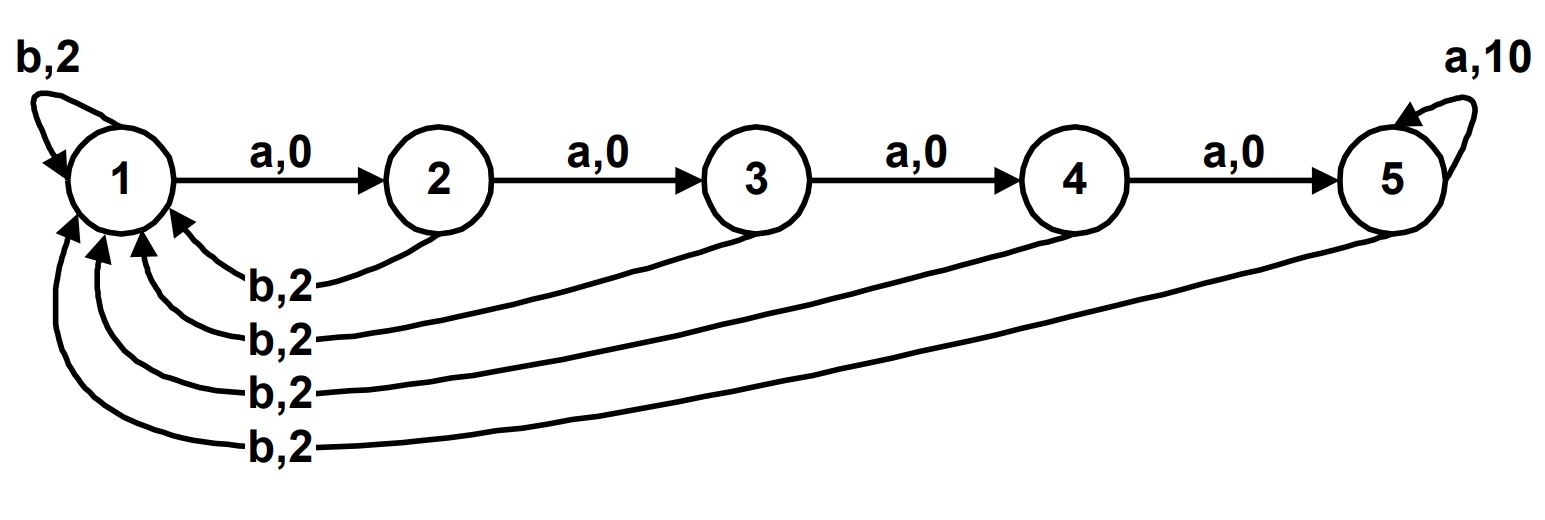

*From ["A Bayesian framework for reinforcement learning", Malcolm Strens](https://www.ece.uvic.ca/~bctill/papers/learning/Strens_2000.pdf).*

### Let's define the parameters of this problem, *i.e.* the transition and the reward functions.

**Exercise**: Use the previous description to define: 
- the *transition probabilities* as a numpy array of shape $(\# \mathcal{A}, \#\mathcal{S}, \#\mathcal{S})$, *i.e.* the first dimension relates to the chosen action, the second dimension to the current state, and the last one to the next state,
- and the reward function as a numpy array of shape $(\#\mathcal{A}, \#\mathcal{S})$, *i.e.* the first dimension relates to the chosen action and the second one to the current state.

In [ ]:
import numpy as np
# Sizes of the state/action spaces
nbS, nbA = 5, 2

# Actions
actions = ['a', 'b']

# Problem parameters: probability values and rewards
pr, pr_last = 0.9, 0.8
rstay, rmax = 2, 10

# Transition matrices dims = (action, current state, next state)
T = np.zeros((nbA, nbS, nbS))
print(T.shape)

# Reward vectors dims = (action, state)
R = np.zeros((nbA, nbS))

# From first states
for i in range(nbS-1):
    T[0, i, i+1] = # HERE
    T[0, i, 0] = # HERE
    T[1, i, 0] = # HERE
    T[1, i, i+1] = # HERE
    R[1, i] = # HERE

# From the last state
T[0, nbS-1, nbS-1] = # HERE
T[0, nbS-1, 0] = # HERE
T[1, nbS-1, 0] = # HERE
T[1, nbS-1, nbS-1] = # HERE
R[0, nbS-1] = # HERE
R[1, nbS-1] = # HERE



# Check that the transition matrix contains probability distributions
print('\n-- Check the transition function --')
#action_names = ['a','b']
action_names = ['go_right','return  ']

for a in range(2):
    if np.any(np.sum(T[a,:,:],axis=1)==np.ones(nbS)):
        print('transition matrix for action <', action_names[a], '> (normalized).')
        print(T[a,:,:])
    else:
        print('WARNING: transition matrix of action <', action_names[a], '> is NOT normalized.')
        print(T[a,:,:])
    
# Print reward vectors
print("\n-- Check the reward function --")
for a in range(2):
    print(' - reward for action <', action_names[a], '> - ')
    print(R[a,:])

### Solve this problem using the Value Iteration (VI) algorithm.
**Exercise**: The following function defines the VI algorithm. Fill the `vtemp` variable with the Dynamic Programming equation:
$$V_{n+1}(s) = \max_{a \in \mathcal{A}} \Big( r(s,a) + \gamma \sum_{s' \in \mathcal{S}} T(s,a,s') V_n(s') \Big). $$

*Tip 1*: To compute the matrix operation between the transition matrix `t` and the value function (vector) `v`, you should use the function [np.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) of Numpy.

*Tip 2*: use [np.max(R, axis=0)](https://stackoverflow.com/questions/33569668/numpy-max-vs-amax-vs-maximum) to get an array containing the max of each column of matrix R.


In [ ]:
# t: transition function (matrices)
# r: reward function (vectors)
# gamma: discount factor
# epsilon: precision
def value_iteration(t,r,gamma,epsilon):
    v = np.max(r,axis=0)
    # Dynamic Programming equation
    vtemp = # HERE
    n=0
    while np.linalg.norm(v-vtemp)>epsilon:
        v = vtemp
        # Dynamic Programming equation
        vtemp = # HERE
        n += 1
    return v, n

# Plot the Value function for gamma = 0.8 and epsilon = 10
import matplotlib.pyplot as plt
gamma, epsilon = 0.8, 10
V, n_iterations = value_iteration(T, R, gamma, epsilon)
print('Number of iterations:', n_iterations)
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.bar(range(5),V)
plt.xlabel('State')
plt.ylabel('Value function')
plt.show()

**Exercise**: Extract the policy (strategy) associated to the Value function $V$ (Value vector `value_function`), by computing the Q-value, *i.e.* the matrix `Q` with shape $(\# \mathcal{A}, \# \mathcal{S})$, still using function [np.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) of Numpy.

In [ ]:
Q = # HERE

# The optimal policy is the greedy policy
# associated to the optimal Q value:
opt_pol = np.argmax(Q,axis=0)
print('Policy:', [actions[i] for i in opt_pol])

**Exercise**: Now, compute the Value function with VI, with a precision $\epsilon=0.1$ and the same discount factor $\gamma=0.8$.

In [ ]:
# Plot the Value function for gamma = 0.8 and epsilon = 0.1
V, n_iterations = # HERE
print('Number of iterations:', n_iterations)
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.bar(range(5),V)
plt.xlabel('State')
plt.ylabel('Value function')
plt.show()

# Policy extraction
Q = # HERE

# The optimal policy is the greedy policy
# associated to the optimal Q value:
opt_pol = # HERE
print('Policy:', [actions[i] for i in opt_pol])
print('States:', np.array(range(1,nbS+1)))

**Exercise**: Finally, compute the Value function with VI, with a discount factor $\gamma=0.9$. and a precision $\epsilon=0.1$.

In [ ]:
# Plot the Value function for gamma = 0.9 and epsilon = 0.1
V, n_iterations = # HERE
print('Number of iterations:', n_iterations)
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.bar(range(5),V)
plt.xlabel('State')
plt.ylabel('Value function')
plt.show()

# Policy extraction
Q = # HERE

# The optimal policy is the greedy policy
# associated to the optimal Q value:
opt_pol =       # HERE
print('Policy:', [actions[i] for i in opt_pol])
print('States:', np.array(range(1,nbS+1)))

**Exercise**: In order to compute the Value function, and the needed number of iterations, for different values of $\gamma$ and $\varepsilon$, let's define with [np.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html):
- `gammas` as an array with $50$ numbers evenly spaced over the interval $[0.01,0.99]$,
- and `epsilons` as an array with $50$ numbers evenly spaced over the interval $[0.01,10]$.

In the `for` loop, the discount factor used $\gamma$ is `X[i,j]` and the precision used $\varepsilon$ is `Y[i,j]`:
- compute the Value function `V` and the number of iterations `n_iterations`,
- define `value[i,j]` as $\sum_{s \in \mathcal{S}} V(s)$, and `n_iter[i,j]` as the number of iterations.

In [ ]:
# values of gamma
gammas = # HERE
# values of epsilon
epsilons = # HERE

# Create a meshgrid for 3d-plotting
X, Y = np.meshgrid(gammas,epsilons)
value = np.zeros((epsilons.size,gammas.size))
n_iter = np.zeros((epsilons.size,gammas.size))
# Compute the Value functions and the number of iterations for each value of the meshgrid
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # use value_iteration with gamma=X[i,j] and epsilon=Y[i,j]
        V, n_iterations = # HERE
        # compute and store the sum of V
        value[i,j] = # HERE
        # store the number of iterations
        n_iter[i,j] = # HERE

# plot of the sum of the values of the Value Function
fig=plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')
ax = plt.axes(projection='3d')
ax.view_init(elev=20., azim=120)
ax.plot_surface(X, Y, value)
plt.rcParams['axes.titley'] = 1.0
plt.rcParams['axes.titlepad'] = -10
ax.set_title('Sum of the values, as a function of the discount factor gamma and the precision epsilon')
ax.set_xlabel(r'$\gamma$', fontsize=20)
ax.set_ylabel(r'$\epsilon$', fontsize=20)
ax.set_zlabel(r'$\sum_{s \in \mathcal{S}} V(s)$', fontsize=20)
ax.zaxis.labelpad = 15
plt.show()

# plot of the number of iterations
fig=plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')
ax = plt.axes(projection='3d')
ax.view_init(elev=20., azim=120)
ax.plot_surface(X, Y, n_iter)
ax.set_xlabel(r'$\gamma$', fontsize=20)
ax.set_ylabel(r'$\epsilon$', fontsize=20)
ax.set_zlabel('Number of Iterations', fontsize=20)
ax.set_title('Number of iterations used in VI, as a function of the discount factor and the precision')
plt.show()

### Solve the problem using the Policy Iteration (PI) algorithm.
We are now going to implement PI. This algorithm has two steps:
- policy evaluation, *i.e.* computation of $V^{\pi}(s) = \mathbb{E}\Big[ \sum_{t=0}^{+\infty} \gamma^t r\big(S_t,\pi(S_t)\big) \Big]$,

- policy improvement, *i.e.* computation of the Q-value $Q^{\pi}(s,a) = r(s,a) + \gamma \sum_{s' \in \mathcal{S}} T(s,a,s') V(s')$ and extraction of the greedy policy $\pi(s) = argmax_{a \in \mathcal{A}} Q(s,a)$.

When evaluating the policy, we use the transition matrix and the reward vector associated to this policy. This is the purpose of the following function.

In [ ]:
def transition_reward_from_policy(transition, reward, policy):
    # reward vector
    state_reward = np.zeros(nbS, dtype=np.float64)
    # transition matrix
    trans_markov_chain = np.eye(nbS, dtype=np.float64)
    for s in range(nbS):
        # action selected by the policy for this state
        index = policy[s]
        # transition distribution from this state with this action
        trans_markov_chain[s] = transition[index, s]
        # reward associated to this state and this action
        state_reward[s] = reward[index,s]
    return trans_markov_chain, state_reward

Let's consider a policy:

In [ ]:
# set the seed for reproducible random numbers
np.random.seed(42)
p = np.random.randint(0,2, size=5)
print('Policy:', [actions[i] for i in p])

The associated transition matrix and reward are:

In [ ]:
t, r = transition_reward_from_policy(T, R, p)
print('Transition matrix:\n', t)
print('\nReward vector:\n', r)

We can now evaluate a policy $\pi \in \mathcal{A} \rightarrow \mathcal{S}$ given its transition matrix $T$ and its reward vector $r$, *i.e.* compute the Value function associated with this policy.

- A first method is to iterate the Bellman Equation (like in the Value Iteration algorithm without the $\max_{a \in \mathcal{A}}$).

- It can also be solved using by solving a linear equation:
$$ V = r + \gamma T V$$ 
$$\Rightarrow  (Id - \gamma T)V = r$$ 
$$\Rightarrow  V = (Id - \gamma T)^{-1}r. $$

**Exercise**: Solve the linear system of the Bellman equation using the function `transition_reward_from_policy`, and functions [np.eye](https://numpy.org/devdocs/reference/generated/numpy.eye.html), [np.linalg.inv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) and [np.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) of Numpy. 

In [ ]:
def policy_evaluation(transition, reward, policy, gamma):
    # Compute the transition matrix and the reward vector
    t, r  = # HERE
    # Compute the matrix Identity - gamma*T
    z = np.eye(t.shape[0], dtype=np.float64) - gamma * t   
    #print(z) # HERE
    # Inverse this matrix
    z = # HERE
    # Multiply the inverse by the reward vector
    v = # HERE
    return v


# Test this function on the previous arbitrary policy.
np.random.seed(42)
p = np.random.randint(0,2, size=5)
v = policy_evaluation(T, R, p, 0.9)
print('Policy:', [actions[i] for i in p])
print('States:', np.array(range(1,nbS+1)))
print('Associated Value function:', v)

We are now ready to implement Policy Iteration, iterating policy evaluation (`policy_evaluation`) and policy improvement (computation of $Q$ and extraction of the greedy policy).

**Exercise**: 
- In the initialization part, 
  - define the policy $\pi$ with the greedy policy w.r.t. the Q-value (inialized as the reward function), 
  - use `policy_evaluation` to compute $V^{\pi}$, 
  - compute the associated Q-value $Q^{\pi}$, 
  - and extract the greedy policy in `new_pol`.
- Do the same work in the `while` loop using `new_pol` as initial policy.

In [ ]:
def policy_iteration(t, r, gamma):
    # INITIALIZATION
    # q value initialized as the reward function
    q = np.copy(r)
    # extract the greedy policy w.r.t. the reward function 
    policy = # HERE
    print('initialization -> pol = ', [actions[i] for i in policy])

    # POLICY EVALUATION
    # evaluate this policy, i.e. compute the associated value function
    v =  # HERE
    
    # POLICY IMPROVEMENT
    # compute the Q value associated to the value function
    q = # HERE
    # extract the greedy policy w.r.t. the Q value
    new_pol = # HERE
    n = 1
    while np.any(new_pol != policy):
        policy = # HERE
        print('iteration', n, '-> policy = ', [actions[i] for i in policy])

        # POLICY EVALUATION
        # evaluate this policy, i.e. compute the associated value function
        v = # HERE
        print('v:', v)
        # POLICY IMPROVEMENT
        # compute the Q value associated to the value function
        q = # HERE
        print('q:', q)
        # extract the greedy policy w.r.t. the Q value
        new_pol = # HERE
        n += 1
    print('PI ends after', n, 'iterations.')
    return policy

# Computation of the optimal policy with gamma = 0.9
optimal_policy = policy_iteration(T, R, gamma=0.7)
print('\nOptimal policy:', [actions[i] for i in optimal_policy])

With gamma = 0.9 the optimal policy is the one that pushes the agent to go always right!

**Question**: Find the greatest gamma that makes the optimal policy different. How do you explain this result?

**Answer**:

# II - Reinforcement Learning (RL) on a discrete environment
### Install gym
For instance with the following command lines
```console
conda create -n RL_aibt python=3.7
conda activate RL_aibt
conda install -c anaconda ipykernel
conda install -c conda-forge gym-atari
conda install -c conda-forge matplotlib
python -m ipykernel install --user --name=RL_aibt
```
and then using the kernel "RL_aibt".

### Use an Gym RL environment: the Taxi Problem
  
  There are 4 locations (labeled by different letters) and your job is to **pick up the passenger at one location and drop him off in another**. You receive **+20 points for a successful dropoff**, and **lose 1 point for every timestep it takes**. There is also a 10 point penalty for illegal pick-up and drop-off actions.

#### Description
There are four designated locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue). When the episode starts, the taxi starts off at a random square and the passenger is at a random location. The taxi drives to the passenger's location, picks up the passenger, drives to the passenger's destination (another one of the four specified locations), and then drops off the passenger. Once the passenger is dropped off, the episode ends.
    
    Map:
        +---------+
        |R: | : :G|
        | : | : : |
        | : : : : |
        | | : | : |
        |Y| : |B: |
        +---------+

#### Actions
There are 6 discrete deterministic actions:
- 0: move south
- 1: move north
- 2: move east
- 3: move west
- 4: pickup passenger
- 5: drop off passenger
    
#### Observations
There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations. Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.
    
Passenger locations:
- 0: R(ed)
- 1: G(reen)
- 2: Y(ellow)
- 3: B(lue)
- 4: in taxi

Destinations:
- 0: R(ed)
- 1: G(reen)
- 2: Y(ellow)
- 3: B(lue)

#### Rewards
- -1 per step unless other reward is triggered.
- +20 delivering passenger.
- -10  executing "pickup" and "drop-off" actions illegally.

#### Rendering
- blue: passenger
- magenta: destination
- yellow: empty taxi
- green: full taxi
- other letters (R, G, Y and B): locations for passengers and destinations
    
**State space is represented by (taxi_row, taxi_col, passenger_location, destination).**

*From [Taxi-v3 environment](https://gymnasium.farama.org/environments/toy_text/taxi/#taxi) and [Hierarchical Reinforcement Learning with the MAXQ Value Function Decomposition, by Tom Dietterich](https://arxiv.org/pdf/cs/9905014.pdf)*.

The following piece of code imports the Reinforcement Learning toolkit *Gym* (by *OpenAI*) and creates the *Taxi* environment. The `reset()` method is used to initialize the environment.

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
 
# choose an environment
env = gym.make("Taxi-v3", render_mode="rgb_array")
observation, info = env.reset()
print('observation:', observation)
plt.imshow(env.render())

The `action_space` and `observation_space` attributes of the environment, give the structure of respectively the action space, and the state space.

In [ ]:
print("Action Space:", env.action_space)
print("State Space:", env.observation_space)

The formula `((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination` (see documentation) allows to set the state of the environment, by giving the n-uplet `(taxi_row, taxi_col, passenger_location, destination)` as input.

**Exercise**: Put the taxi (yellow) in the middle of the grid, the passenger location at the top left, and the destination at the bottom right.

In [ ]:
# set a state
# (taxi_row, taxi_col, passenger_location, destination)
taxi_row = # HERE
taxi_col = # HERE
passenger_location = # HERE
destination = # HERE
env.unwrapped.s =  # HERE
plt.imshow(env.render())

**Exercise**: Now put the passenger in the taxi (that becomes 
green and remains in the same location).

In [ ]:
# set a new state
# (taxi_row, taxi_col, passenger_location, destination)
taxi_row = # HERE
taxi_col = # HERE
passenger_location = # HERE
destination = # HERE
env.unwrapped.s = # HERE
plt.imshow(env.render())

Now, we would like to sample a **50-steps simulation** of this environment.

**Exercise**: Use the `sample()` method of `env.action_space` to randomly select an action, and the `step()` method of `env`, with the action as input, to generate the next state and the associated reward.

In [ ]:
from IPython.display import clear_output
from time import sleep

# simulation of 50 steps
horizon = 50
n = 0

# start simulation
env.reset()
done = False
while not done:
    # select a random action
    action = # HERE
    
    # use the action, and get next state and reward
    state, reward, terminated, truncated, info = # HERE
    n += 1
    
    # display the state of the system
    clear_output(wait=True)
    print('step', n)
    plt.imshow(env.render())
    plt.show()
    sleep(.2)

    # stops if the horizon is reached
    if n==horizon:
        done = True

#### Executed policy: the $\varepsilon$-greedy policy
Now that we know how to simulate interactions with the environment, we can implement Reinforcement Learning (RL) algorithms.
We will implement *SARSA* and *Q-learning* algorithms whose executed strategy is the $\varepsilon$-greedy policy.
Therefore, let's first implement the $\varepsilon$-greedy policy.

**Exercise**: Here, the Q-value is an array of shape $(\# \mathcal{S}, \# \mathcal{A})$. **Note that dimensions of the Q-value have a different order compared to Section I**.
- First, define `greedy` as the result of a Bernoulli variable with parameter $p = 1- \varepsilon$, *i.e.* a variable $X$ such that $\mathbb{P}(X = true) = 1-\varepsilon$ and $\mathbb{P}(X = false) = \varepsilon$.
- Then, if `greedy` is equal to 1, extract the action associated to the Q-value.
- Otherwise, sample an action from the action space.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt


def epsilon_greedy(epsilon, Q, state):        
    greedy = # HERE
    if greedy: 
        # Exploit learned values
        action =  # HERE
    else:
        # Explore action space
        action = # HERE
    return action
            
# Q-value equal to 0, except for state number 0 = (0,0,0,0) and action number 2 (move east)
q_table = np.zeros([env.observation_space.n, env.action_space.n])
q_table[0,2] = 1

# Sampling actions from the epsilon_greedy function to check the epsilon_greedy function
# Note that the Q-value is maximal in action 2 for state 0: the greedy action is action 2.
sampled_actions = []


for i in range(1000):
    sampled_actions.append(epsilon_greedy(0.5, q_table, 0))

# Display the associated histogram
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.hist(sampled_actions, stacked=True, density=True, bins=[-0.5+i for i in range(7)])
plt.rcParams['axes.titlepad'] = 10
plt.title('Histogram of the actions sampled with the epsilon-greedy policy')
plt.show()

#### Implement the SARSA algorithm
**Exercise**: Use the *SARSA* pseudo-code given in class to fill the following piece of code and run *SARSA* on the *Taxi* environment.

In [ ]:
# SARSA algorithm
# Creation of the Q value function
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1

# For plotting metrics
all_returns = []
avg_returns = []
returns = []

for i in range(1,10000):
    
    # simulation initialization
    state, info = env.reset()
    n, reward, = 0, 0
    
    # start simulation
    reward_disc_sum = 0

    # epsilon greedy action selection
    action =  # HERE

    terminated = False
    
    while not terminated:         
        # apply action to the environment, get next state and reward
        next_state, reward, terminated, truncated, info =  # HERE
        reward_disc_sum += pow(gamma, n) * reward
        
        # epsilon greedy action selection
        next_action = # HERE
        
        # update the Q value function
        old_Qvalue = q_table[state, action]
        next_Q = # HERE
        q_table[state, action] =  # HERE

        # update the system state and the time step variables 
        state = next_state
        action = next_action

        n += 1
    
    all_returns.append(reward_disc_sum)
    returns.append(reward_disc_sum)
    # plot epoch counter
    if i % 100 == 0:
        avg_returns.append(sum(returns)/len(returns))
        clear_output(wait=True)
        print(f"Episode: {i}")

print("Training finished.\n")

fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.plot(all_returns)
plt.xlabel('Episodes')
plt.ylabel('Return')
plt.title('Return for each episode')
plt.show()
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.plot(avg_returns)
plt.xlabel('Episodes')
plt.ylabel('Averaged return every 100 episodes')
plt.show()
print(all_returns[:10])

**Exercise**: Evaluate the resulting policy:
- Compute the greedy action (w.r.t. the computed Q-value),
- Compute the return `reward_disc_sum` $= r_0 + \gamma r_1 + \gamma^2 r_2 + \gamma^3 r_3 + \ldots$.

In [ ]:
episodes = 1000
horizon = 100
avg_return, total_epochs = 0, 0

for _ in range(episodes):
    state, info = env.reset()
    n, reward, reward_disc_sum = 0, 0, 0
    terminated = False
    
    while not terminated:
        # select the greedy action
        action = # HERE

        # evolution of the system state
        state, reward, terminated, truncated, info = env.step(action)

        # computation of the return
        reward_disc_sum +=  # HERE

        n += 1
        # stop if the horizon is reached
        if n==horizon:
            terminated = True
    total_epochs += n
    avg_return += reward_disc_sum

print("Results after", episodes, "episodes:")
print("Average return per episode:", avg_return/episodes)
print("Average timesteps per episode:", total_epochs/episodes)

**Exercise**: Same tasks for a simulation display.

In [ ]:
n, reward, reward_disc_sum = 0, 0, 0
horizon = 100
state, info = env.reset()
terminated = False    

while not terminated:
    # display the state of the system
    clear_output(wait=True)
    print('step', n)
    plt.imshow(env.render())
    plt.show()
    sleep(.2)
    
    # select the greedy action
    action =      # HERE
    state, reward, terminated, truncated, info = env.step(action)
    reward_disc_sum += # HERE
    
    # stop if the horizon is reached
    if n==horizon:
        terminated = True
        
    n += 1
    
print('Return:', reward_disc_sum)

The Q-value does not seem to have been well estimated. You can try other parameters to improve the learning process:
- the learning rate $\alpha \in [0,1]$,
- the exploration ratio $\varepsilon \in [0,1]$,
- the number of episodes.

#### Implement the Q learning algorithm
The difference between *Q-learning* and *SARSA* is the updating of the Q-value: 
- *SARSA* uses the action of the policy that is executed (SARSA is said to be "on-policy"), 
- and *Q-learning* uses the action that maximizes the Q-value. 

Q-learning allows the Q-value to be informed more quickly of promising actions.

**Exercise**: Use the *Q-learning* pseudo-code given in class to fill the following piece of code and run *Q-learning* on the *Taxi* environment.

In [ ]:
# Creation of the Q value function
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1

# For plotting metrics
all_returns = []
avg_returns = []
returns = []

for i in range(1, 10000):
    
    # simulation initialization
    state, info = env.reset()
    n, reward, = 0, 0
    terminated = False
    
    # start simulation
    reward_disc_sum = 0
    while not terminated:
        # epsilon greedy action selection
        action = # HERE
         
        # apply action to the environment, get next state and reward
        next_state, reward, terminated, truncated, info = # HERE
        reward_disc_sum += pow(gamma, n) * reward
        
        # update the Q value function
        old_Qvalue = q_table[state, action]
        next_Qmax =  # HERE
        q_table[state, action] = # HERE

        # update the system state and the time step variables 
        state = next_state
        n += 1
    
    all_returns.append(reward_disc_sum)
    returns.append(reward_disc_sum)
    # plot epoch counter
    if i % 100 == 0:
        avg_returns.append(sum(returns)/len(returns))
        clear_output(wait=True)
        print(f"Episode: {i}")

print("Training finished.\n")

fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.plot(all_returns)
plt.xlabel('Episodes')
plt.ylabel('Return')
plt.title('Return for each episode')
plt.show()
fig=plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
plt.plot(avg_returns)
plt.xlabel('Episodes')
plt.ylabel('Averaged return every 100 episodes')
plt.show()

**Exercise**: Evaluate the resulting policy.

In [ ]:
episodes = 1000
horizon = 100
avg_return, total_epochs = 0, 0

for _ in range(episodes):
    state, info = env.reset()
    n, reward, reward_disc_sum = 0, 0, 0
    terminated = False
    
    while not terminated:
        # select the greedy action
        action = # HERE

        # evolution of the system state
        state, reward, terminated, truncated, info = env.step(action)

        # computation of the return
        reward_disc_sum += # HERE

        n += 1
        # stop if the horizon is reached
        if n==horizon:
            terminated = True
    total_epochs += n
    avg_return += reward_disc_sum

print("Results after", episodes, "episodes:")
print("Average return per episode:", avg_return/episodes)
print("Average timesteps per episode:", total_epochs/episodes)

**Exercise**:  Same tasks for a simulation display.

In [ ]:
n, reward, reward_disc_sum = 0, 0, 0
horizon = 100
state, info = env.reset()
terminated = False    

while not terminated:
    # display the state of the system
    clear_output(wait=True)
    print('step', n)
    plt.imshow(env.render())
    plt.show()
    sleep(.2)
    
    # select the greedy action
    action = # HERE
    state, reward, terminated, truncated, info = env.step(action)
    reward_disc_sum += # HERE
    
    # stop if the horizon is reached
    if n==horizon:
        terminated = True
        
    n += 1
    
print('Return:', reward_disc_sum)

<div class="alert alert-block alert-warning"> <b>Please let us know when you reach Section III.</b> </div> 

# III - Another environment
**Exercise**: Implement the *Q-learning* algorithm on the following environments:
- plot the returns and averaged returns over episodes,
- evaluate the computed policy,
- display a simulation with the computed policy.

## [Frozen Lake](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/)
*Find a safe path across a grid of ice and water tiles.*

The agent controls the movement of a character in a grid world. Some tiles of the grid are walkable, and others lead to the agent falling into the water. Additionally, the movement direction of the agent is uncertain and only partially depends on the chosen direction. The agent is rewarded for finding a walkable path to a goal tile.

Frozen lake involves crossing a frozen lake from Start(S) to Goal(G) without falling into any Holes(H) by walking over the Frozen(F) lake. The agent may not always move in the intended direction due to the slippery nature of the frozen lake.

#### Action Space
The agent takes a 1-element vector for actions. The action space is `(dir)`, where `dir` decides direction to move in which can be:
- 0: LEFT
- 1: DOWN
- 2: RIGHT
- 3: UP

#### Observation Space
The observation is a value representing the agent's current position as current_row * nrows + current_col (where both the row and col start at 0). For example, the goal position in the 4x4 map can be calculated as follows: 3 * 4 + 3 = 15. The number of possible observations is dependent on the size of the map. For example, the 4x4 map has 16 possible observations.
    
#### Rewards
Reward schedule:
- Reach goal(G): +1
- Reach hole(H): 0
- Reach frozen(F): 0

#### Arguments

    gym.make('FrozenLake-v1', desc=None,map_name="4x4", is_slippery=True)
    
- `desc`: Used to specify custom map for frozen lake. For example, desc=["SFFF", "FHFH", "FFFH", "HFFG"].

- `map_name`: ID to use any of the preloaded maps.
        
        "4x4":
           ["SFFF",
            "FHFH",
            "FFFH",
            "HFFG"]
            
        "8x8":
           ["SFFFFFFF",
            "FFFFFFFF",
            "FFFHFFFF",
            "FFFFFHFF",
            "FFFHFFFF",
            "FHHFFFHF",
            "FHFFHFHF",
            "FFFHFFFG"]
        
- `is_slippery`: True/False. If True will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions. For example, if action is left and is_slippery is True, then:
        - P(move left)=1/3
        - P(move up)=1/3
        - P(move down)=1/3
        
        
**Exercise**: Run the *Q-learning* algorithm on *FrozenLake 4x4*, plot the returns and averaged returns over episodes, evaluate the computed policy, and display a simulation with the computed policy.

In [ ]:
env.close()
env = gym.make("FrozenLake-v1", render_mode="rgb_array")
observation, info = env.reset()
print('observation:', observation)
plt.imshow(env.render())

**Exercise**: Run the *Q-learning* algorithm on *FrozenLake 8x8*, plot the returns and averaged returns over episodes, evaluate the computed policy, and display a simulation with the computed policy.

In [ ]:
env.close()
env = gym.make("FrozenLake-v1", map_name="8x8", render_mode="rgb_array")
observation, info = env.reset()
print('observation:', observation)
plt.imshow(env.render())